# はじめに

このノートではProphetライブラリをPythonで利用する方法をまとめておく。内容としては、時系列データの理解、特徴量エンジニアリング、クロスバリデーション、パラメタチューニング、将来の予測までをまとめる。時系列分析に関する数理的な要素や分析の正当性については、ここでは扱わない。前回はProphetで一連の処理を実行できるようにしたので、ここでは関数化することで処理を簡潔にまとめる。

- [prophet](https://facebook.github.io/prophet/)

同様の予測をLightGBMでも行っていおり、下記より確認できる。

- [LightGBMと時系列データ分析](https://github.com/SugiAki1989/statistical_note/blob/main/note_LightGBM17/note_LightGBM17.ipynb)


下記が関数化したもので、この下のブロックで処理内容を簡単にまとめる。

In [33]:
import logging
import os
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from prophet import Prophet
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import jpholiday

# ----------------------------
# グローバル設定
# ----------------------------
# 特徴量作成用のパラメータ
LAGS = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
WINDOWS = LAGS  # 同じ値を使用
EXPANSIONS = LAGS  # 同じ値を使用

# データ設定
START_DATE = '2018-07-01'
FORECAST_PERIODS = 7

# ----------------------------
# ログ設定
# ----------------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logging.getLogger().setLevel(logging.INFO)
logger = logging.getLogger(__name__)
# # Optunaのログを完全に無効化
# # Prophetとcmdstanpyのログを非表示
# optuna.logging.set_verbosity(optuna.logging.ERROR)
# logging.getLogger('prophet').setLevel(logging.ERROR)
# logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# ----------------------------
# 1. データ読み込み・前処理
# ----------------------------


def load_data(filepath):
    logger.info("Loading data from %s", filepath)
    df = pd.read_csv(filepath)[['date', 'pageviews']].rename(columns={'date': 'ds', 'pageviews': 'y'})
    df['ds'] = pd.to_datetime(df['ds'])
    df = df[df['ds'] >= pd.to_datetime(START_DATE)]
    logger.info("Data loaded and filtered: %d rows", len(df))
    return df

# ----------------------------
# 2. 未来データ追加
# ----------------------------


def add_future_dates(df, periods=FORECAST_PERIODS):
    logger.info("Adding %d future dates", periods)
    future_dates = pd.date_range(df['ds'].max() + pd.Timedelta(days=1), periods=periods)
    return pd.DataFrame({'ds': future_dates, 'y': np.nan})

# ----------------------------
# 3. 特徴量作成
# ----------------------------


def create_features(df):
    logger.info("Creating features")

    # グローバル変数を使用
    for lag in LAGS:
        df[f'lag{lag}'] = df['y'].shift(lag)

    for w in WINDOWS:
        df[f'win{w}'] = df['y'].shift(1).rolling(window=w, min_periods=1).mean()

    for exp in EXPANSIONS:
        df[f'expan{exp}'] = df[f'lag{exp}'].expanding().mean()

    df['weekday'] = df['ds'].dt.weekday
    weekday_dummies = pd.get_dummies(df['weekday'], prefix='wd', drop_first=False)
    df = pd.concat([df, weekday_dummies], axis=1)

    df['is_tuesday'] = df['ds'].dt.weekday == 1
    df['is_jholiday'] = df['ds'].apply(lambda x: jpholiday.is_holiday(x))

    regressors = [
        *[f'lag{l}' for l in LAGS],
        *[f'win{w}' for w in WINDOWS],
        *[f'expan{e}' for e in EXPANSIONS],
        *[f'wd_{i}' for i in range(7)],
        'is_tuesday',
        'is_jholiday'
    ]
    logger.info("Feature creation complete")
    return df, regressors

# ----------------------------
# 4. Optuna用Objective関数
# ----------------------------


def objective(trial, df, regressors):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10),
        'weekly_fourier': trial.suggest_int('weekly_fourier', 3, 7),
        'weekly_prior': trial.suggest_float('weekly_prior', 1, 12)
    }

    cv_mae = []
    tss = TimeSeriesSplit(n_splits=5)

    for train_idx, valid_idx in tss.split(df):
        train_data, valid_data = df.iloc[train_idx].copy(), df.iloc[valid_idx].copy()

        m = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='additive'
        )

        for reg in regressors:
            m.add_regressor(reg)

        m.add_seasonality('weekly', period=7, fourier_order=params['weekly_fourier'], prior_scale=params['weekly_prior'])
        m.fit(train_data)
        preds = m.predict(valid_data)
        mae = mean_absolute_error(valid_data['y'], preds['yhat'])
        cv_mae.append(mae)

    avg_mae = np.mean(cv_mae)
    logger.debug("Trial complete - MAE: %.4f", avg_mae)
    return avg_mae

# ----------------------------
# 5. Prophet モデル作成
# ----------------------------


def build_prophet_model(params, regressors):
    logger.info("Building Prophet model with best parameters")
    model = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive'
    )
    for reg in regressors:
        model.add_regressor(reg)
    model.add_seasonality('weekly', period=7, fourier_order=params['weekly_fourier'], prior_scale=params['weekly_prior'])
    return model

# ----------------------------
# 6. 再帰的予測
# ----------------------------


def recursive_forecast(df, model, feature_cols, future_index, lags, wins, expans):
    logger.info("Starting recursive forecast")
    for idx in future_index:
        for lag in lags:
            full_idx = idx - lag
            if full_idx in df.index:
                df.at[idx, f'lag{lag}'] = df.at[full_idx, 'yhat'] if pd.isna(df.at[full_idx, 'y']) else df.at[full_idx, 'y']

        for win in wins:
            lag_vals = [df.at[i, f'lag{win}'] for i in range(idx - win + 1, idx + 1) if i in df.index and not pd.isna(df.at[i, f'lag{win}'])]
            df.at[idx, f'win{win}'] = np.mean(lag_vals) if lag_vals else np.nan

        for expan in expans:
            exp_vals = [df.at[i, f'lag{expan}'] for i in range(0, idx) if not pd.isna(df.at[i, f'lag{expan}'])]
            df.at[idx, f'expan{expan}'] = np.mean(exp_vals) if exp_vals else np.nan

        input_row = df.loc[[idx], ['ds'] + feature_cols]
        forecast = model.predict(input_row)
        df.at[idx, 'yhat'] = forecast.at[0, 'yhat']
        df.at[idx, 'yhat_lower'] = forecast.at[0, 'yhat_lower']
        df.at[idx, 'yhat_upper'] = forecast.at[0, 'yhat_upper']
    logger.info("Recursive forecast complete")
    return df

# ----------------------------
# 7. 予測プロット関数
# ----------------------------


def plot_forecast(df: pd.DataFrame, title: str = "Forecast plot") -> None:
    logger.info("Plotting forecast")
    plt.figure(figsize=(14, 6))
    plt.plot(df['ds'], df['y'], label='Actual (y)', color='gray', alpha=0.7)
    plt.plot(df['ds'], df['yhat'], label='Forecast (yhat)', color='#006E4F')
    plt.fill_between(df['ds'], df['yhat_lower'], df['yhat_upper'], color='#006E4F', alpha=0.1, label='Confidence Interval')
    plt.axvline(pd.to_datetime('2019-09-01'), color='gray', linestyle='--', alpha=0.7, label='Forecast Start')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('y')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

`load_data`関数ではcsvのファイルパスを読み込みデータをフィルタリングして整える。

In [34]:
# データ読み込み
df = load_data('../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv')
df

2026-01-17 12:01:39,653 - INFO - Loading data from ../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv
2026-01-17 12:01:39,657 - INFO - Data loaded and filtered: 427 rows


,ds,y
668,2018-07-01,294
669,2018-07-02,697
670,2018-07-03,652
671,2018-07-04,688
672,2018-07-05,746
...,...,...
1090,2019-08-27,1256
1091,2019-08-28,1133
1092,2019-08-29,1142
1093,2019-08-30,1004


`add_future_dates`関数は予測した日付を作成する関数。

In [35]:
# 未来の空データ追加
forecast_df = add_future_dates(df)
forecast_df

2026-01-17 12:01:39,665 - INFO - Adding 7 future dates


,ds,y
0,2019-09-01,NaN
1,2019-09-02,NaN
2,2019-09-03,NaN
3,2019-09-04,NaN
4,2019-09-05,NaN
5,2019-09-06,NaN
6,2019-09-07,NaN


In [36]:
# 過去＋未来データを統合
full_df = pd.concat([df, forecast_df], ignore_index=True)
full_df

,ds,y
0,2018-07-01,294.0
1,2018-07-02,697.0
2,2018-07-03,652.0
3,2018-07-04,688.0
4,2018-07-05,746.0
...,...,...
429,2019-09-03,NaN
430,2019-09-04,NaN
431,2019-09-05,NaN
432,2019-09-06,NaN


`create_features`関数は、過去＋未来の統合済みデータをもとに必要なラグ特徴量やダミー変数を作成する。

In [37]:
# 特徴量作成
full_df, regressors = create_features(full_df)
full_df

2026-01-17 12:01:39,680 - INFO - Creating features
2026-01-17 12:01:39,688 - INFO - Feature creation complete


,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,weekday,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday
0,2018-07-01,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6,False,False,False,False,False,False,True,False,False
1,2018-07-02,697.0,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,True,False,False,False,False,False,False,False,False
2,2018-07-03,652.0,697.0,294.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,False,True,False,False,False,False,False,True,False
3,2018-07-04,688.0,652.0,697.0,294.0,NaN,NaN,NaN,NaN,NaN,...,2,False,False,True,False,False,False,False,False,False
4,2018-07-05,746.0,688.0,652.0,697.0,294.0,NaN,NaN,NaN,NaN,...,3,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2019-09-03,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1098.0,...,1,False,True,False,False,False,False,False,True,False
430,2019-09-04,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1161.0,...,2,False,False,True,False,False,False,False,False,False
431,2019-09-05,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1235.0,...,3,False,False,False,True,False,False,False,False,False
432,2019-09-06,NaN,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1034.0,...,4,False,False,False,False,True,False,False,False,False


In [38]:
# 特徴量列のリスト作成
feature_cols = full_df.columns.difference(['ds', 'y']).tolist()
# 学習/評価用データ抽出（欠損除外）
train_test_df = full_df[full_df[feature_cols].notna().all(axis=1) & full_df['y'].notna()].copy()
# 学習・テストに分割
train_df, test_df = train_test_split(train_test_df, test_size=62)

`Optuna用Objective`関数は、Optunaによるハイパーパラメータチューニングのための関数。パラメタを探索しながら、Prophetモデルを構築し、訓練データでモデルを学習させる。その後、評価データに対して予測を行い、予測値と実測値の平均絶対誤差（MAE）を計算して返す。Optunaの最適化プロセスでは、この関数が繰り返し呼び出され、MAEが最小となるハイパーパラメータの組み合わせを探索する。 

> study = optuna.create_study(direction='minimize') \
study.optimize(lambda trial: objective(trial, train_df, regressors), n_trials=100, n_jobs=4)\
best_params = study.best_params\

例…\
{'changepoint_prior_scale': 0.01863653077817969,
 'seasonality_prior_scale': 6.605193694773952,
 'weekly_fourier': 7,
 'weekly_prior': 10.979411971400518}\

 順序の関係はここはマークダウンで結果を記載している。

In [39]:
best_params = {'changepoint_prior_scale': 0.01863653077817969,
               'seasonality_prior_scale': 6.605193694773952,
               'weekly_fourier': 7,
               'weekly_prior': 10.979411971400518}

`build_prophet_model`関数はチューニングされたパラメタとリグレッサーを受け取って、Prophetモデルを構築する。

2026-01-17 12:01:39,716 - INFO - Building Prophet model with best parameters
2026-01-17 12:01:39,845 - INFO - Test MAE: 113.2159
2026-01-17 12:01:39,847 - INFO - Plotting forecast


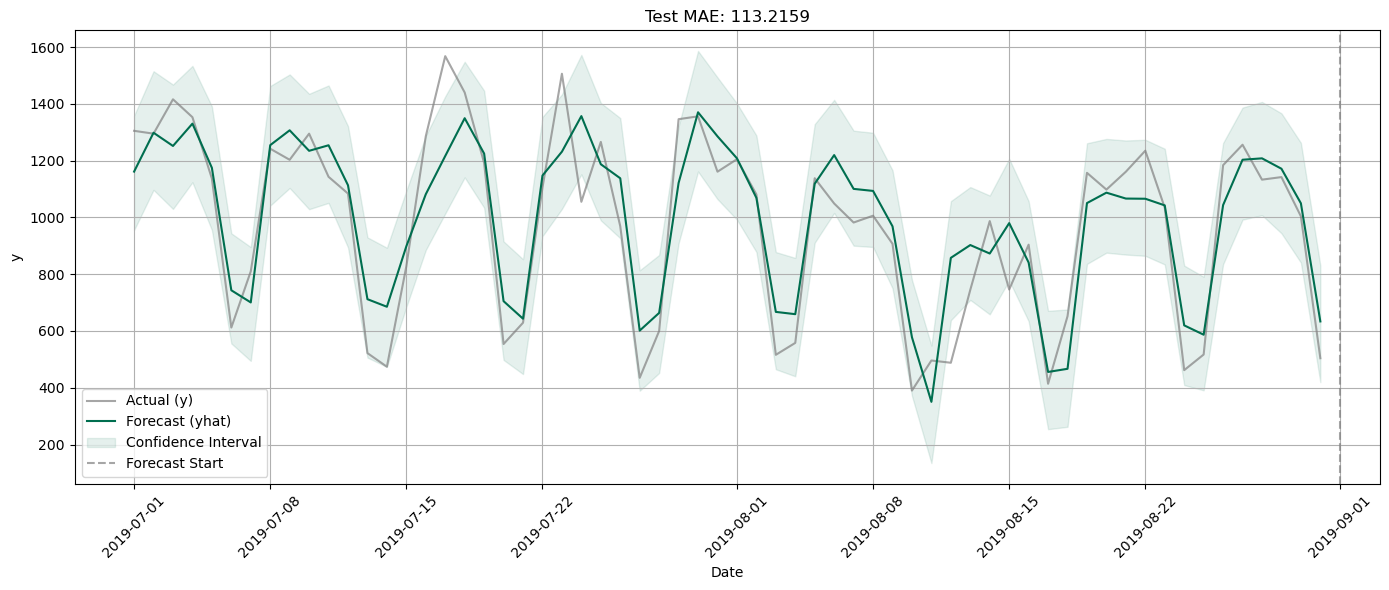

In [40]:
# モデル構築（テスト用）
model = build_prophet_model(best_params, regressors)
# テスト用モデル学習
model.fit(train_df)

# テストデータ予測
pred = model.predict(test_df)
mae = mean_absolute_error(test_df['y'], pred['yhat'])
logger.info("Test MAE: %.4f", mae)
plot_forecast(test_df.merge(pred, on='ds', how='left'), title=f"Test MAE: {mae:.4f}")

In [41]:
# フルモデル構築＆学習（テスト＋学習データ）
full_model = build_prophet_model(best_params, regressors)
full_model.fit(train_test_df)

2026-01-17 12:01:39,966 - INFO - Building Prophet model with best parameters


`recursive_forecast`関数は予測の際に再帰予測が必要になるので、再帰予測を実行している関数。

In [42]:
# 再帰予測のための未来インデックス取得
future_index = full_df[full_df['y'].isna()].index
# グローバル変数を使用
lags = LAGS
wins = WINDOWS
expans = EXPANSIONS
# 再帰的に未来を予測
full_df = recursive_forecast(full_df, full_model, feature_cols, future_index, lags, wins, expans)  # 予測結果のデータフレーム作成
full_df.tail(10)

2026-01-17 12:01:40,042 - INFO - Starting recursive forecast
2026-01-17 12:01:40,331 - INFO - Recursive forecast complete


,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday,yhat,yhat_lower,yhat_upper
424,2019-08-29,1142.0,1133.000000,1256.000000,1184.000000,517.000000,462.000000,1034.000000,1235.0,746.0,...,False,True,False,False,False,False,False,NaN,NaN,NaN
425,2019-08-30,1004.0,1142.000000,1133.000000,1256.000000,1184.000000,517.000000,462.000000,1034.0,904.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
426,2019-08-31,504.0,1004.000000,1142.000000,1133.000000,1256.000000,1184.000000,517.000000,462.0,414.0,...,False,False,False,True,False,False,False,NaN,NaN,NaN
427,2019-09-01,NaN,504.000000,1004.000000,1142.000000,1133.000000,1256.000000,1184.000000,517.0,652.0,...,False,False,False,False,True,False,False,588.909731,386.006591,797.008665
428,2019-09-02,NaN,588.909731,504.000000,1004.000000,1142.000000,1133.000000,1256.000000,1184.0,1157.0,...,False,False,False,False,False,False,False,1096.535773,877.438146,1294.044954
429,2019-09-03,NaN,1096.535773,588.909731,504.000000,1004.000000,1142.000000,1133.000000,1256.0,1098.0,...,False,False,False,False,False,True,False,1139.688434,947.271268,1348.638941
430,2019-09-04,NaN,1139.688434,1096.535773,588.909731,504.000000,1004.000000,1142.000000,1133.0,1161.0,...,True,False,False,False,False,False,False,1077.832098,881.567364,1281.075292
431,2019-09-05,NaN,1077.832098,1139.688434,1096.535773,588.909731,504.000000,1004.000000,1142.0,1235.0,...,False,True,False,False,False,False,False,1085.473099,894.530679,1284.685089
432,2019-09-06,NaN,1085.473099,1077.832098,1139.688434,1096.535773,588.909731,504.000000,1004.0,1034.0,...,False,False,True,False,False,False,False,986.558609,788.598430,1190.919195
433,2019-09-07,NaN,986.558609,1085.473099,1077.832098,1139.688434,1096.535773,588.909731,504.0,462.0,...,False,False,False,True,False,False,False,570.567831,367.158820,775.351082


In [43]:
# def recursive_forecast(df, model, feature_cols, future_index, lags, wins, expans):
#    logger.info("Starting recursive forecast")
#
#    # 未来の各時点に対して再帰的予測を実行
#    for idx in future_index:
#
#        # ========================================
#        # 1. ラグ特徴量の更新
#        # ========================================
#        for lag in lags:
#            # 過去のラグ期間のインデックスを計算 例：idx=427番目の将来レコードを計算する場合で、lag=1のとき、full_idx=426番目のレコードのデータを使用している
#            full_idx = idx - lag
#
#            # インデックスが有効な場合のみ処理
#            if full_idx in df.index:
#                # 過去データがある場合は実測値、ない場合は予測値を使用
#                df.at[idx, f'lag{lag}'] = df.at[full_idx, 'yhat'] if pd.isna(df.at[full_idx, 'y']) else df.at[full_idx, 'y']
#

あとは可視化のための処理を行う。

2026-01-17 12:01:40,429 - INFO - Plotting forecast


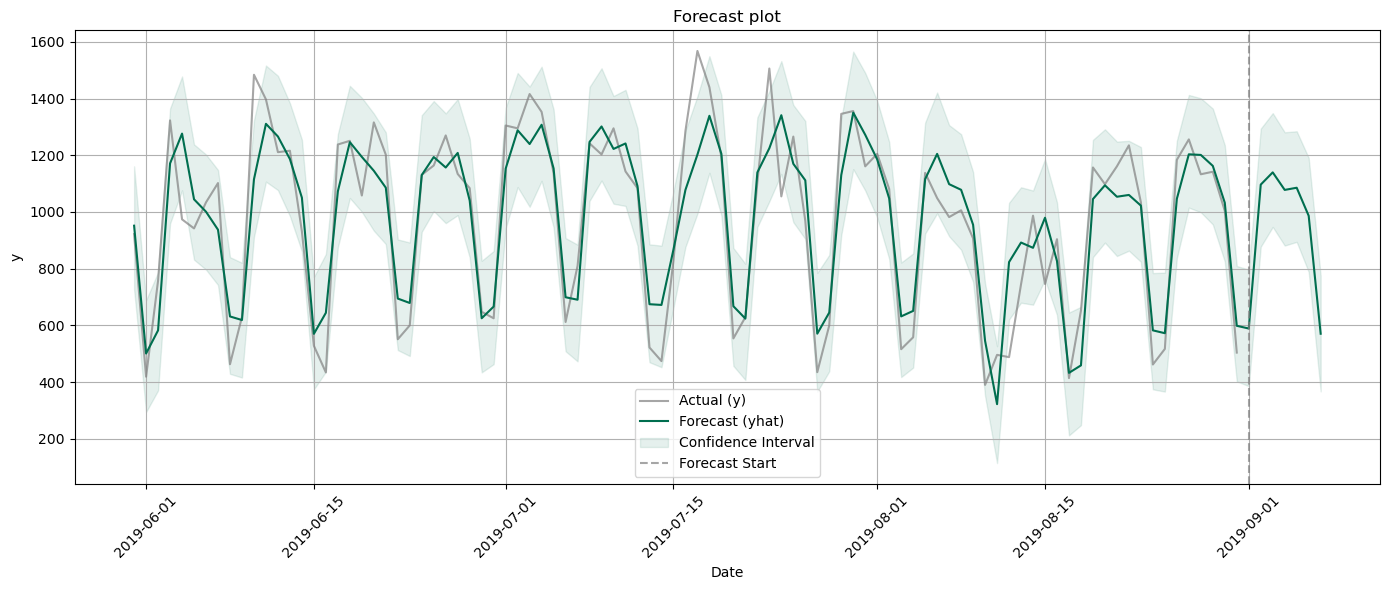

In [44]:
pred_train = train_df.merge(full_model.predict(train_df), on='ds', how='left')
pred_test = test_df.merge(full_model.predict(test_df), on='ds', how='left')
pred_forecast = full_df.loc[future_index, ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]
# 予測・実測の結合（直近100件）
result_df = pd.concat([
    pred_train[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
    pred_test[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
    pred_forecast
]).sort_values('ds').tail(100)
# プロット表示
plot_forecast(result_df)

In [45]:
# # ----------------------------
# # メイン処理
# # ----------------------------
# if __name__ == '__main__':
#     # パイプライン開始ログ
#     logger.info("Pipeline started")
#     # データ読み込み
#     df = load_data('../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv')
#     # 未来の空データ追加
#     forecast_df = add_future_dates(df)
#     # 過去＋未来データを統合
#     full_df = pd.concat([df, forecast_df], ignore_index=True)
#     # 特徴量作成
#     full_df, regressors = create_features(full_df)
#     # 特徴量列のリスト作成
#     feature_cols = full_df.columns.difference(['ds', 'y']).tolist()
#     # 学習/評価用データ抽出（欠損除外）
#     train_test_df = full_df[full_df[feature_cols].notna().all(axis=1) & full_df['y'].notna()].copy()
#     # 学習・テストに分割
#     train_df, test_df = train_test_split(train_test_df, test_size=62)
#     # Optuna によるハイパーパラメータチューニング開始
#     logger.info("Starting hyperparameter tuning")
#     study = optuna.create_study(direction='minimize')
#     # 最適化実行
#     study.optimize(lambda trial: objective(trial, train_df, regressors), n_trials=100, n_jobs=4)
#     # 最良パラメータ取得
#     best_params = study.best_params
#     logger.info("Best params found: %s", best_params)
#     # モデル構築（テスト用）
#     model = build_prophet_model(best_params, regressors)
#     # テスト用モデル学習
#     model.fit(train_df)

#     # テストデータ予測
#     pred = model.predict(test_df)
#     mae = mean_absolute_error(test_df['y'], pred['yhat'])
#     logger.info("Test MAE: %.4f", mae)
#     plot_forecast(test_df.merge(pred, on='ds', how='left'), title=f"Test MAE: {mae:.4f}")

#     # フルモデル構築＆学習（テスト＋学習データ）
#     full_model = build_prophet_model(best_params, regressors)
#     full_model.fit(train_test_df)
#     # 再帰予測のための未来インデックス取得
#     future_index = full_df[full_df['y'].isna()].index
#     # グローバル変数を使用
#     lags = LAGS
#     wins = WINDOWS
#     expans = EXPANSIONS
#     # 再帰的に未来を予測
#     full_df = recursive_forecast(full_df, full_model, feature_cols, future_index, lags, wins, expans)  # 予測結果のデータフレーム作成
#     logger.info("Generating result DataFrame")
#     pred_train = train_df.merge(full_model.predict(train_df), on='ds', how='left')
#     pred_test = test_df.merge(full_model.predict(test_df), on='ds', how='left')
#     pred_forecast = full_df.loc[future_index, ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]
#     # 予測・実測の結合（直近100件）
#     result_df = pd.concat([
#         pred_train[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
#         pred_test[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']],
#         pred_forecast
#     ]).sort_values('ds').tail(100)
#     # プロット表示
#     plot_forecast(result_df)
#     # パイプライン完了ログ
#     logger.info("Pipeline completed")